In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Load cleaned dataset
df = pd.read_csv('/content/drive/MyDrive/AI Project Stage 2/final_cleaned_dataset-2.csv')
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (106574, 416)


In [3]:
# Exclude metadata and target columns dynamically
meta_cols = [
    'track_id',
    'genre_top',
    'split',
    'target_listens',
    'target_listens_log',
    'target_tier',
]
feature_cols = [
    c
    for c in df.columns
    if c not in meta_cols and df[c].dtype in ['float64', 'int64']
]

# Drop any zero-variance columns
feature_cols = [c for c in feature_cols if df[c].std() > 0]

X = df[feature_cols]
print(f'Total Audio Features Selected for PCA: {X.shape[1]}')

Total Audio Features Selected for PCA: 410


In [4]:
# Standardize features (mean = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled Data Sample:')
print(X_scaled[:3, :5])

Scaled Data Sample:
[[ 3.15869637  0.94001203 -0.73290852 -0.47611279 -0.541568  ]
 [-0.43010143 -0.60361044 -0.60878306 -0.32457697  0.18353833]
 [-0.13301861 -1.01795977 -0.22509706  0.08228644  0.08938772]]


In [5]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained and cumulative variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f'PC1 Explained Variance: {explained_var[0]*100:.2f}%')
print(f'PC2 Explained Variance: {explained_var[1]*100:.2f}%')
print(f'PC1 + PC2 Cumulative Variance: {cumulative_var[1]*100:.2f}%')

PC1 Explained Variance: 12.05%
PC2 Explained Variance: 8.94%
PC1 + PC2 Cumulative Variance: 20.99%


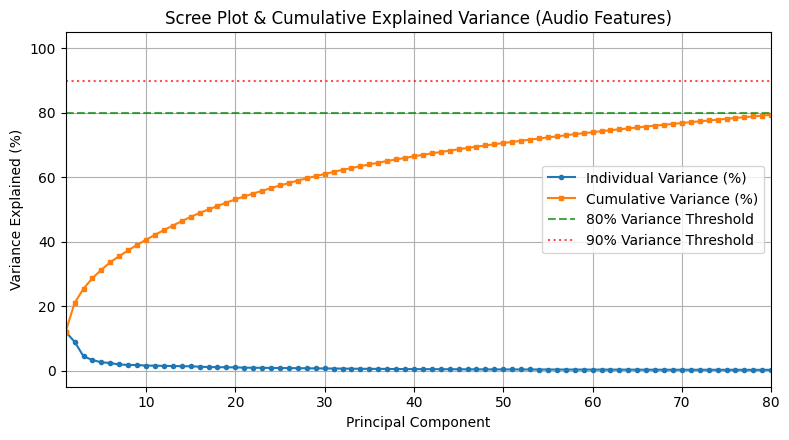

In [6]:
# Scree Plot
plt.figure(figsize=(8, 4.5))

plt.plot(
    range(1, len(explained_var) + 1),
    explained_var * 100,
    marker='o',
    markersize=3,
    label='Individual Variance (%)',
)
plt.plot(
    range(1, len(cumulative_var) + 1),
    cumulative_var * 100,
    marker='s',
    markersize=3,
    label='Cumulative Variance (%)',
)

plt.axhline(
    y=80,
    color='green',
    linestyle='--',
    alpha=0.7,
    label='80% Variance Threshold',
)
plt.axhline(
    y=90, color='red', linestyle=':', alpha=0.7, label='90% Variance Threshold'
)

plt.title('Scree Plot & Cumulative Explained Variance (Audio Features)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.xlim(1, 80)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Find number of PCs to keep
num_pcs_80 = np.argmax(cumulative_var >= 0.80) + 1
num_pcs_90 = np.argmax(cumulative_var >= 0.90) + 1

print(
    f'Number of PCs for >= 80% variance: {num_pcs_80} / {len(feature_cols)}'
    f' ({(1 - num_pcs_80/len(feature_cols))*100:.1f}% reduction)'
)
print(
    f'Number of PCs for >= 90% variance: {num_pcs_90} / {len(feature_cols)}'
    f' ({(1 - num_pcs_90/len(feature_cols))*100:.1f}% reduction)'
)

Number of PCs for >= 80% variance: 83 / 410 (79.8% reduction)
Number of PCs for >= 90% variance: 141 / 410 (65.6% reduction)


/tmp/ipykernel_2129/1558226160.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


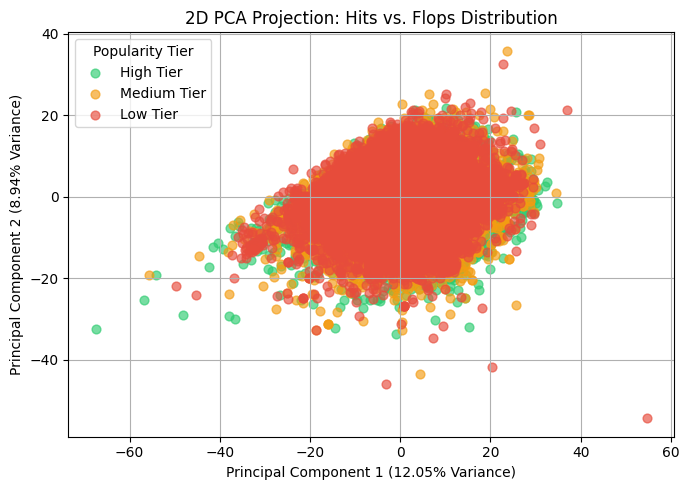

In [8]:
# 2D PCA DataFrame (Dynamically named columns using explained_var)
pc1_name = f"PC1 ({explained_var[0]*100:.2f}%)"
pc2_name = f"PC2 ({explained_var[1]*100:.2f}%)"

pca_2d_df = pd.DataFrame(
    data=X_pca[:, :2],
    columns=[pc1_name, pc2_name]
)
pca_2d_df['target_tier'] = df['target_tier'].values

# Plot 2D projection
plt.figure(figsize=(7, 5))
colors = {'high': '#2ecc71', 'medium': '#f39c12', 'low': '#e74c3c'}

for tier, color in colors.items():
    subset = pca_2d_df[pca_2d_df['target_tier'] == tier]
    plt.scatter(
        subset[pc1_name],
        subset[pc2_name],
        c=color,
        label=f'{tier.capitalize()} Tier',
        alpha=0.65,
        s=40,
    )

plt.title('2D PCA Projection: Hits vs. Flops Distribution')
plt.xlabel(f'Principal Component 1 ({explained_var[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]*100:.2f}% Variance)')
plt.legend(title='Popularity Tier')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Feature loadings for top components
loadings = pd.DataFrame(
    pca.components_[:num_pcs_80, :].T,
    columns=[f'PC{i+1}' for i in range(num_pcs_80)],
    index=feature_cols,
)

print('Feature Loadings Sample (First 5 PCs):')
print(loadings[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].head(10))

Feature Loadings Sample (First 5 PCs):
                             PC1       PC2       PC3       PC4       PC5
chroma_cqt_kurtosis_01 -0.000005 -0.042483  0.037756  0.046291  0.042888
chroma_cqt_kurtosis_02  0.000997 -0.044668  0.039052  0.045749  0.052121
chroma_cqt_kurtosis_03  0.001680 -0.037205  0.048568  0.058439  0.044103
chroma_cqt_kurtosis_04  0.005063 -0.043515  0.041403  0.058699  0.051742
chroma_cqt_kurtosis_05  0.006270 -0.037776  0.044582  0.069482  0.027093
chroma_cqt_kurtosis_06  0.007659 -0.043804  0.042946  0.068208  0.039851
chroma_cqt_kurtosis_07  0.006882 -0.042041  0.049324  0.069035  0.033772
chroma_cqt_kurtosis_08 -0.000241 -0.036731  0.050058  0.063490  0.020166
chroma_cqt_kurtosis_09 -0.000578 -0.044007  0.050199  0.060974  0.026362
chroma_cqt_kurtosis_10  0.000711 -0.037115  0.058420  0.067114  0.016575


In [10]:
# Actually verify which features drive each component, sorted by magnitude
print("Top 5 features per component (sorted by |loading|):\n")
for pc in [f'PC{i+1}' for i in range(5)]:
    top5 = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"--- {pc} ---")
    print(top5)
    print()

Top 5 features per component (sorted by |loading|):

--- PC1 ---
spectral_contrast_mean_02      0.112653
spectral_contrast_mean_03      0.111576
spectral_contrast_median_02    0.109965
spectral_contrast_median_03    0.109015
spectral_contrast_mean_04      0.105002
Name: PC1, dtype: float64

--- PC2 ---
mfcc_max_08                     0.115354
mfcc_max_10                     0.114253
mfcc_max_06                     0.108481
mfcc_max_12                     0.106824
spectral_rolloff_kurtosis_01    0.105023
Name: PC2, dtype: float64

--- PC3 ---
mfcc_mean_07      0.146627
mfcc_median_07    0.145880
zcr_median_01     0.144340
zcr_mean_01       0.140865
mfcc_median_09    0.133095
Name: PC3, dtype: float64

--- PC4 ---
chroma_stft_min_02    0.130098
chroma_stft_min_01    0.129818
chroma_stft_min_12    0.129748
chroma_stft_min_04    0.129744
chroma_stft_min_03    0.129460
Name: PC4, dtype: float64

--- PC5 ---
spectral_contrast_median_07     0.135471
spectral_contrast_mean_07       0.135143
to